In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Carga desde un archivo .csv sin indice
citasd= pd.read_csv('Analisis GAC Full7agosto 2026(Citas Digital).csv') 

C:\Users\maria\AppData\Local\Temp\ipykernel_18276\2919218338.py:2: DtypeWarning: Columns (0: BDC , 1: Fecha, 2: Nombre Cliente , 3: Telefono , 4: Estatus de Lead, 5: Potencial de compra, 6: PDM, 7: SDC, 8: Venta, 9: Asesor Asignado, 10: ¿Por que no ha visitado la agencia?, 11: ¿Por que no hay solicitud de credito?, 12: ¿Por que no hubo prueba de manejo ?, 13: ¿Por que no hubo proceso wow?, 14: ¿Por que se asigno antes de vistar piso?, 15: Unnamed: 15) have mixed types. Specify dtype option on import or set low_memory=False.
  citasd= pd.read_csv('Analisis GAC Full7agosto 2026(Citas Digital).csv')


In [6]:
#Verificamos información del DataFrame
citasd.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 16 columns):
 #   Column                                    Non-Null Count    Dtype 
---  ------                                    --------------    ----- 
 0   BDC                                       673 non-null      str   
 1   Fecha                                     88 non-null       str   
 2   Nombre Cliente                            668 non-null      str   
 3   Telefono                                  2 non-null        str   
 4   Estatus de Lead                           654 non-null      str   
 5   Potencial de compra                       614 non-null      str   
 6   PDM                                       1048574 non-null  object
 7   SDC                                       1048573 non-null  object
 8   Venta                                     1048570 non-null  object
 9   Asesor Asignado                           656 non-null      str   
 10  ¿Por que no ha visitado la ag

In [7]:
#Imprimo los primeros 5 registro del dataframe
citasd.head()

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Potencial de compra,PDM,SDC,Venta,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Unnamed: 15
0,Saul,NaN,Guillermo,NaN,Finalizado,90%,TRUE,False,False,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",Comenta que no se le hizo atractivo el arrenda...
1,Saul,NaN,Roberto,NaN,Finalizado,40%,FALSE,False,False,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,NaN
2,Saul,NaN,Irving,NaN,Finalizado,85%,FALSE,False,False,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,Se le manda msj de seguimiento 03/05/2025
3,Saul,NaN,Oswaldo,NaN,Venta,90%,FALSE,False,True,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",NaN
4,Saul,NaN,Rodrigo,NaN,Finalizado,90%,TRUE,False,False,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,Por el detalle del carbilink compro en otra ma...


Estatus del lead - ¿En qué estatus se concentra actualmente la mayor cantidad de leads digitales?

In [8]:
# Reviso los valores de la variable
citasd["Estatus de Lead"].unique()

<StringArray>
['Finalizado ',      'Venta ',     'Activo ',     'Acitvo ',           nan,
          '11',       'Venta',  'Finalizado',      'Activo',      'Acrivo',
      'activo',       'Ativo',     'Antonio',     'Activio',     'Activo-']
Length: 15, dtype: str

In [14]:
# Limpio espacios y convierto todo a minúsculas
citasd["Estatus de Lead"] = (
    citasd["Estatus de Lead"]
    .str.strip()
    .str.lower()
)

In [17]:
#Corregimos los typos
citasd["Estatus de Lead"] = citasd["Estatus de Lead"].replace({

    # Activo
    "activo": "Activo",
    "actvio": "Activo",
    "acrivo": "Activo",
    "acitvo": "Activo",
    "ativo": "Activo",
    "antonio": "Activo",
    "activio": "Activo",
    "activo-": "Activo",

    # Finalizado
    "finalizado": "Finalizado",
    "finalizado'": "Finalizado",

    # Venta
    "venta": "Venta",
    "venta'": "Venta"

})

In [24]:
#limpiar el 11 que no sabemos a que se refiere a nan

citasd["Estatus de Lead"] = citasd["Estatus de Lead"].replace(
    "11", np.nan
)

In [25]:
#Corroboramos que ya solamente sean las 3 categorias que deben de ser originalmente
citasd["Estatus de Lead"].unique()

<StringArray>
['Finalizado', 'Venta', 'Activo', nan]
Length: 4, dtype: str

In [27]:
# Obtengo un análisis univariado de la variable categórica

Tabla_freq_estatus = (
    citasd["Estatus de Lead"]
    .value_counts()
    .reset_index()
)

Tabla_freq_estatus

,Estatus de Lead,count
0,Activo,603
1,Finalizado,29
2,Venta,21


In [28]:
# Obtengo un filtro de los valores más relevantes
# de la variable categórica seleccionada

Filtro_estatus = Tabla_freq_estatus[
    Tabla_freq_estatus["count"] > 1
]

Filtro_estatus

,Estatus de Lead,count
0,Activo,603
1,Finalizado,29
2,Venta,21


In [29]:
# Ajusto el índice de mi dataframe

Filtro_estatus_index = Filtro_estatus.set_index(
    "Estatus de Lead"
)

Filtro_estatus_index

,count
Estatus de Lead,
Activo,603
Finalizado,29
Venta,21


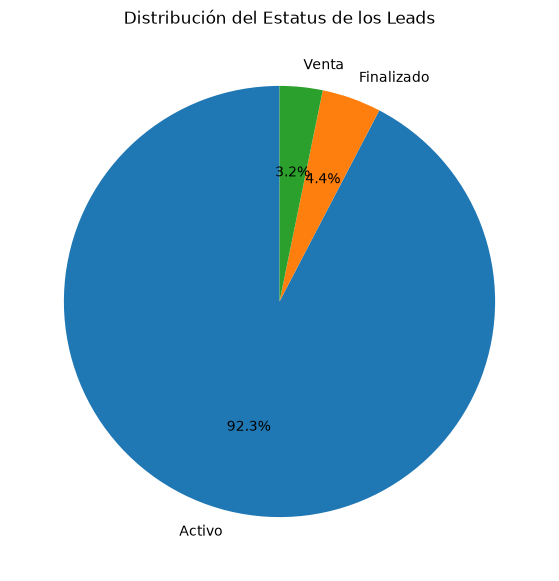

In [30]:
# Creo la gráfica de pastel
plt.figure(figsize=(7, 7))

plt.pie(
    Tabla_freq_estatus["count"],
    labels=Tabla_freq_estatus["Estatus de Lead"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución del Estatus de los Leads")

plt.show()